In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
from scipy import sparse
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

BASE_DIR = Path("/data5/zhangye/scMRDR/output/BMMC/scMRDR_results_rna_to_protein")
ratio_label = "single_000"   # 改这里，比如 single_020 / single_040 ...
outdir = BASE_DIR / ratio_label

FIGDIR = BASE_DIR / "figures" / ratio_label
FIGDIR.mkdir(parents=True, exist_ok=True)

print("Using:", outdir)

Using: /data5/zhangye/scMRDR/output/BMMC/scMRDR_results_rna_to_protein/single_000


In [2]:
pred_protein_val = sc.read_h5ad(outdir / "pred_protein_val.h5ad")
true_protein_val = sc.read_h5ad(outdir / "true_protein_val.h5ad")

t1_metrics = pd.read_csv(outdir / "T1_metrics_protein_space.csv")
t2_metrics = pd.read_csv(outdir / "T2_metrics_protein.csv")
t1_per_cell = pd.read_csv(outdir / "T1_per_cell_metrics_protein_space.csv")
t2_cellwise = pd.read_csv(outdir / "T2_cellwise_pearson_protein.csv")
t2_featurewise = pd.read_csv(outdir / "T2_featurewise_pearson_protein.csv")

print(pred_protein_val.shape, true_protein_val.shape)
display(t1_metrics)
display(t2_metrics)

(16658, 102) (16658, 102)


,metric,value
0,paired_embedding_distance_mean,86.459662
1,paired_embedding_distance_median,57.590132
2,FOSCTTM,0.487793
3,Top1_ACC,0.000000
4,Top5_ACC,0.000180
5,Top10_ACC,0.000840


,metric,value
0,pearson_cell_mean,0.719595
1,pearson_feature_mean,0.264425
2,rmse,10.758019


In [3]:
def to_dense(x):
    if sparse.issparse(x):
        return x.toarray()
    return np.asarray(x)

def scale_rows(mat):
    mat = np.asarray(mat, dtype=float)
    row_mean = np.nanmean(mat, axis=1, keepdims=True)
    row_std = np.nanstd(mat, axis=1, keepdims=True)
    row_std[row_std == 0] = 1.0
    return (mat - row_mean) / row_std

def get_common_names(*arrays):
    if len(arrays) == 0:
        return []
    common = set(arrays[0])
    for arr in arrays[1:]:
        common &= set(arr)
    return sorted(common)

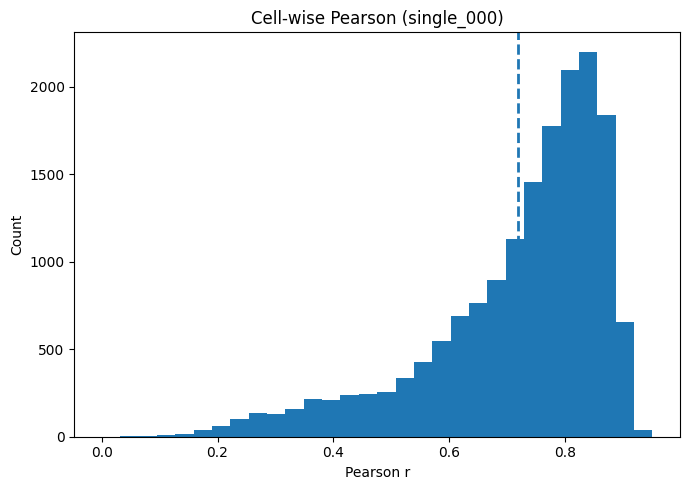

In [4]:
cell_cor = t2_cellwise["cellwise_pearson"].to_numpy()

plt.figure(figsize=(7, 5))
plt.hist(cell_cor[~np.isnan(cell_cor)], bins=30)
plt.axvline(np.nanmean(cell_cor), linestyle="--", linewidth=2)
plt.xlabel("Pearson r")
plt.ylabel("Count")
plt.title(f"Cell-wise Pearson ({ratio_label})")
plt.tight_layout()
plt.savefig(FIGDIR / "Fig2_cellwise_pearson_hist.png", dpi=200)
plt.show()

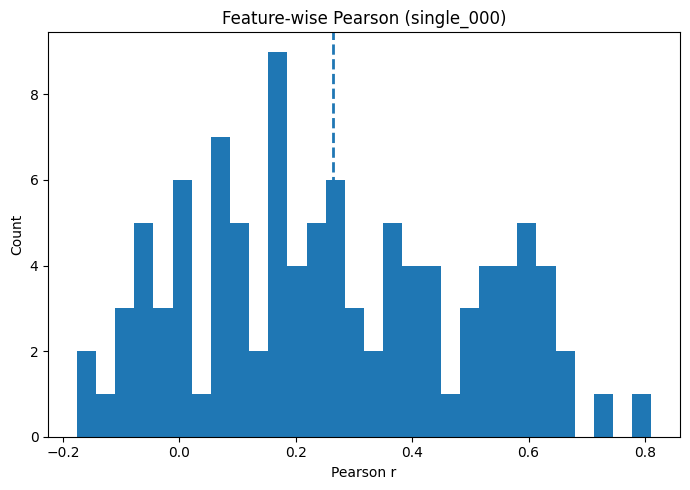

In [5]:
feature_cor = t2_featurewise["featurewise_pearson"].to_numpy()

plt.figure(figsize=(7, 5))
plt.hist(feature_cor[~np.isnan(feature_cor)], bins=30)
plt.axvline(np.nanmean(feature_cor), linestyle="--", linewidth=2)
plt.xlabel("Pearson r")
plt.ylabel("Count")
plt.title(f"Feature-wise Pearson ({ratio_label})")
plt.tight_layout()
plt.savefig(FIGDIR / "Fig3_featurewise_pearson_hist.png", dpi=200)
plt.show()

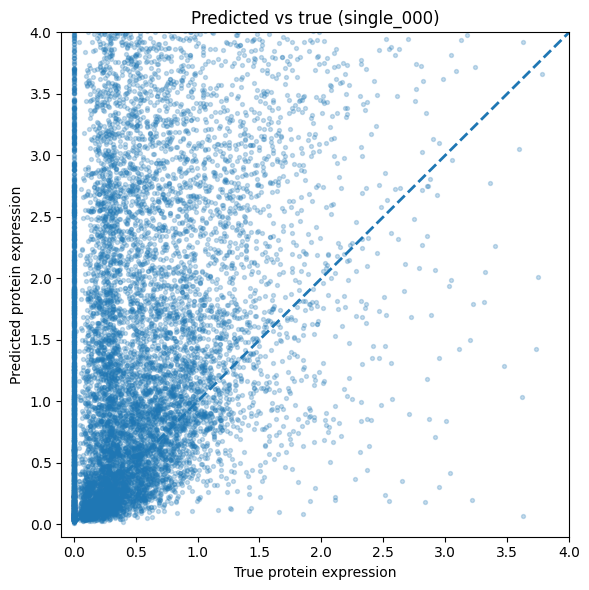

In [6]:
common_cells = get_common_names(pred_protein_val.obs_names.tolist(), true_protein_val.obs_names.tolist())
common_features = get_common_names(pred_protein_val.var_names.tolist(), true_protein_val.var_names.tolist())

pred_use = pred_protein_val[common_cells, common_features].copy()
true_use = true_protein_val[common_cells, common_features].copy()

pred_vec = to_dense(pred_use.X).ravel()
true_vec = to_dense(true_use.X).ravel()

rng = np.random.default_rng(1234)
n_sample = min(20000, len(true_vec))
idx = rng.choice(len(true_vec), size=n_sample, replace=False)

plt.figure(figsize=(6, 6))
plt.scatter(true_vec[idx], pred_vec[idx], s=8, alpha=0.25)
mn = min(true_vec[idx].min(), pred_vec[idx].min())
mx = max(true_vec[idx].max(), pred_vec[idx].max())
plt.plot([mn, mx], [mn, mx], linestyle="--", linewidth=2)
plt.xlim((-0.1,4))
plt.ylim((-0.1,4))
plt.xlabel("True protein expression")
plt.ylabel("Predicted protein expression")
plt.title(f"Predicted vs true ({ratio_label})")
plt.tight_layout()
plt.savefig(FIGDIR / "Fig4_global_pred_vs_true_scatter.png", dpi=200)
plt.show()

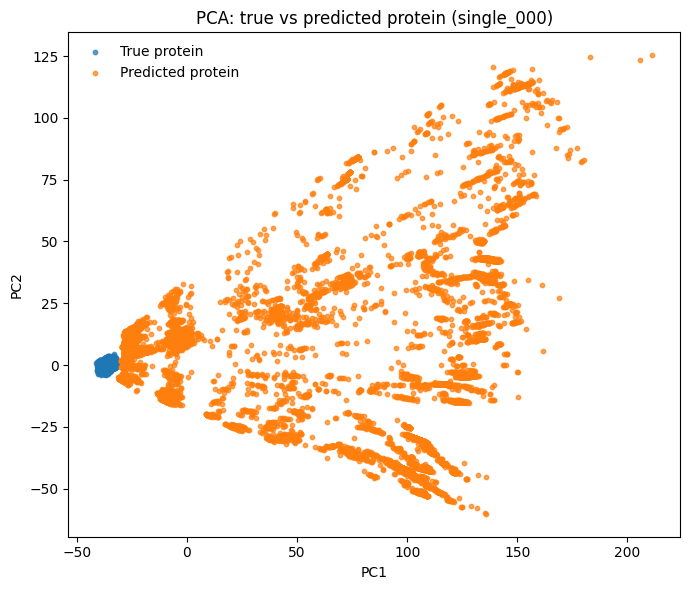

In [7]:
true_mat = to_dense(true_use.X)
pred_mat = to_dense(pred_use.X)

mix = np.vstack([true_mat, pred_mat])   # cells x features
n_components = min(30, mix.shape[0] - 1, mix.shape[1])

pca = PCA(n_components=n_components, random_state=1234)
emb = pca.fit_transform(mix)

nq = true_mat.shape[0]
plot_df = pd.DataFrame({
    "PC1": emb[:, 0],
    "PC2": emb[:, 1],
    "type": ["True_Protein"] * nq + ["Pred_from_RNA"] * nq
})

plt.figure(figsize=(7, 6))
mask_true = plot_df["type"] == "True_Protein"
mask_pred = plot_df["type"] == "Pred_from_RNA"

plt.scatter(plot_df.loc[mask_true, "PC1"], plot_df.loc[mask_true, "PC2"], s=10, alpha=0.7, label="True protein")
plt.scatter(plot_df.loc[mask_pred, "PC1"], plot_df.loc[mask_pred, "PC2"], s=10, alpha=0.7, label="Predicted protein")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"PCA: true vs predicted protein ({ratio_label})")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIGDIR / "Fig5_pca_true_vs_pred.png", dpi=200)
plt.show()

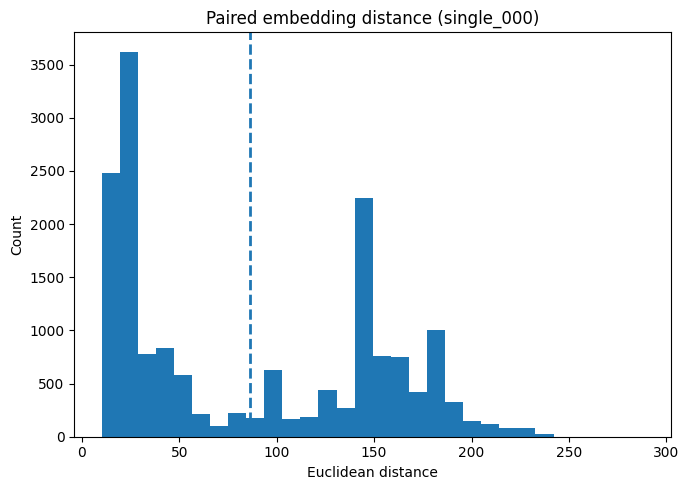

In [8]:
paired_dist = t1_per_cell["paired_dist"].to_numpy()

plt.figure(figsize=(7, 5))
plt.hist(paired_dist[~np.isnan(paired_dist)], bins=30)
plt.axvline(np.nanmean(paired_dist), linestyle="--", linewidth=2)
plt.xlabel("Euclidean distance")
plt.ylabel("Count")
plt.title(f"Paired embedding distance ({ratio_label})")
plt.tight_layout()
plt.savefig(FIGDIR / "Fig6_paired_distance_hist.png", dpi=200)
plt.show()

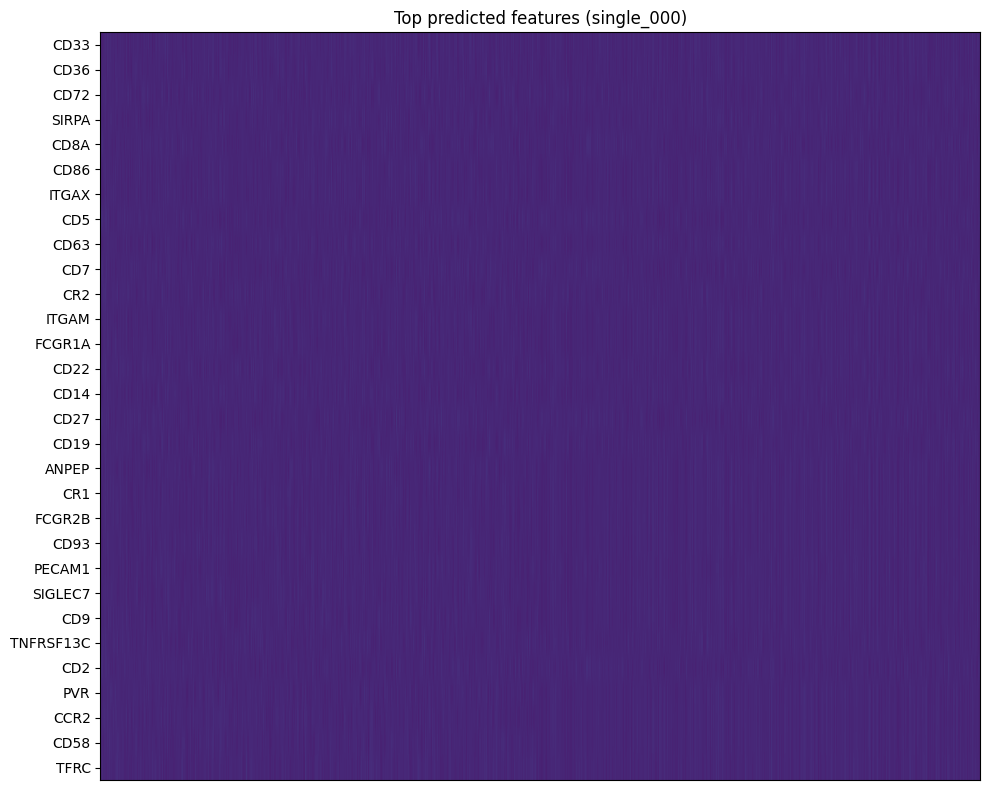

In [9]:
top_n = 30
feature_cor_df = t2_featurewise.dropna().sort_values("featurewise_pearson", ascending=False)
top_features = feature_cor_df["feature"].tolist()[:top_n]

if len(top_features) > 1:
    true_top = to_dense(true_use[:, top_features].X).T   # gene x cell
    pred_top = to_dense(pred_use[:, top_features].X).T   # gene x cell

    true_top_z = scale_rows(true_top)
    pred_top_z = scale_rows(pred_top)
    heatmap_mat = np.concatenate([true_top_z, pred_top_z], axis=1)

    plt.figure(figsize=(10, 8))
    plt.imshow(heatmap_mat, aspect="auto")
    plt.yticks(np.arange(len(top_features)), top_features)
    plt.xticks([])
    plt.title(f"Top predicted features ({ratio_label})")
    plt.tight_layout()
    plt.savefig(FIGDIR / "Fig7_top_feature_heatmap.png", dpi=200)
    plt.show()

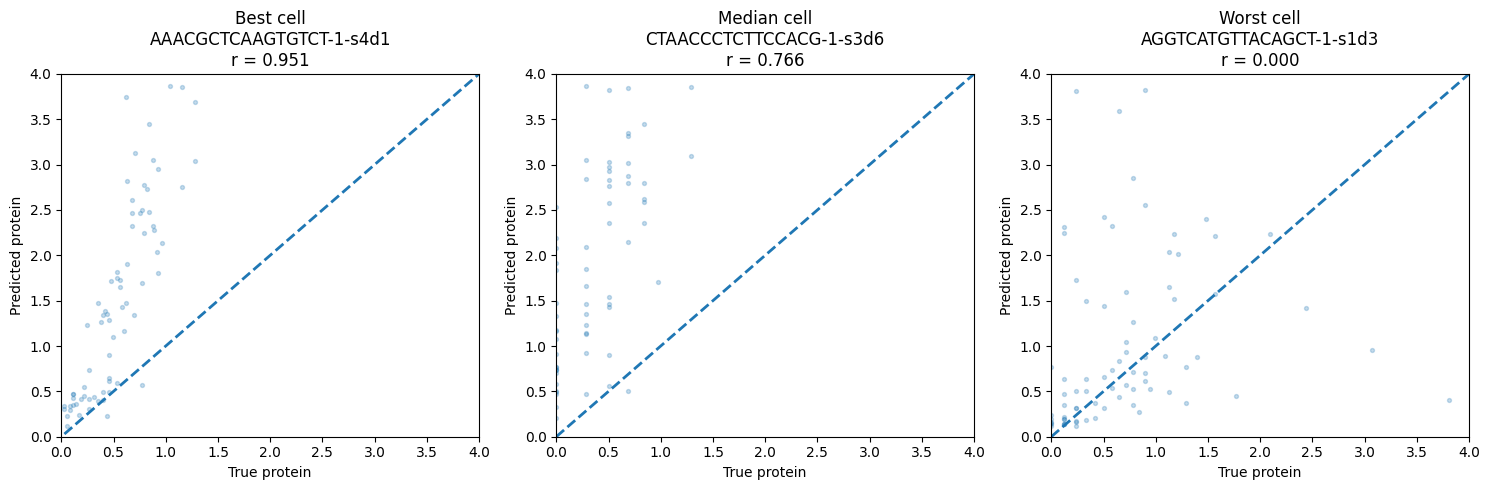

In [10]:
cell_df = t2_cellwise.dropna().sort_values("cellwise_pearson", ascending=False)
ordered_cells = cell_df["cell"].tolist()

if len(ordered_cells) >= 3:
    best_cell = ordered_cells[0]
    median_cell = ordered_cells[len(ordered_cells) // 2]
    worst_cell = ordered_cells[-1]

    example_cells = [best_cell, median_cell, worst_cell]
    labels = ["Best", "Median", "Worst"]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, cell, lab in zip(axes, example_cells, labels):
        x = to_dense(true_use[cell, :].X).ravel()
        y = to_dense(pred_use[cell, :].X).ravel()

        ax.scatter(x, y, s=8, alpha=0.25)
        mn = min(x.min(), y.min())
        mx = max(x.max(), y.max())
        ax.plot([mn, mx], [mn, mx], linestyle="--", linewidth=2)
        r = cell_df.loc[cell_df["cell"] == cell, "cellwise_pearson"].iloc[0]
        ax.set_xlim((0,4))
        ax.set_ylim((0,4))
        ax.set_title(f"{lab} cell\n{cell}\nr = {r:.3f}")
        ax.set_xlabel("True protein")
        ax.set_ylabel("Predicted protein")

    plt.tight_layout()
    plt.savefig(FIGDIR / "Fig8_example_cells_scatter.png", dpi=200)
    plt.show()

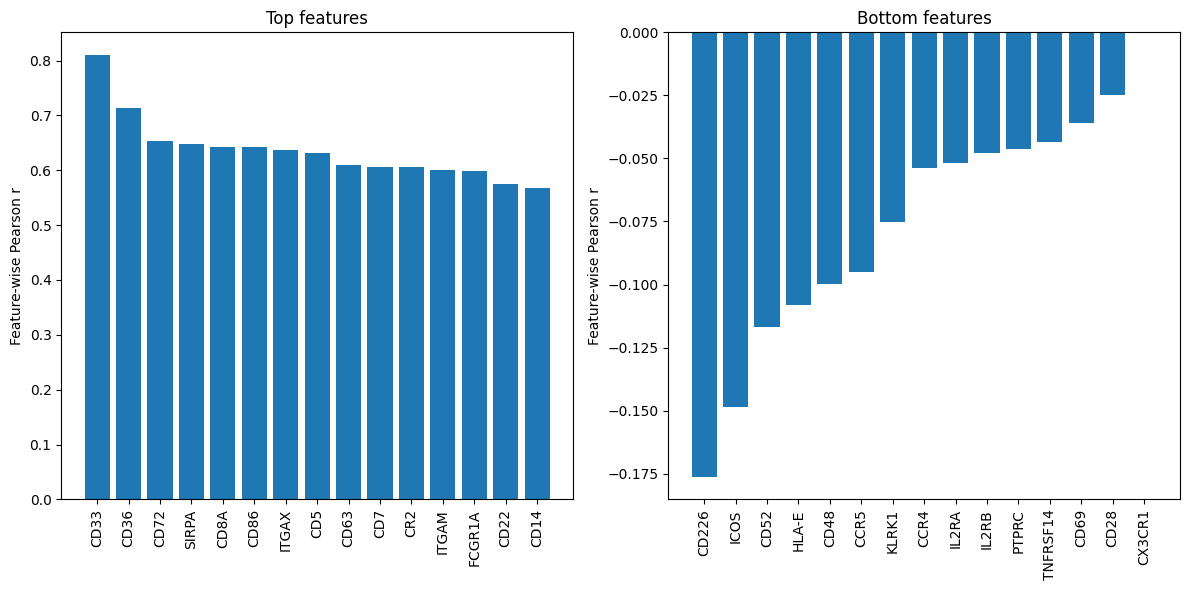

In [11]:
feature_df = t2_featurewise.dropna().sort_values("featurewise_pearson", ascending=False)

if len(feature_df) >= 15:
    top_k = 15
    top_features_bar = feature_df.head(top_k)
    bottom_features_bar = feature_df.tail(top_k).sort_values("featurewise_pearson", ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].bar(np.arange(top_k), top_features_bar["featurewise_pearson"].to_numpy())
    axes[0].set_xticks(np.arange(top_k))
    axes[0].set_xticklabels(top_features_bar["feature"].tolist(), rotation=90)
    axes[0].set_title("Top features")
    axes[0].set_ylabel("Feature-wise Pearson r")

    axes[1].bar(np.arange(top_k), bottom_features_bar["featurewise_pearson"].to_numpy())
    axes[1].set_xticks(np.arange(top_k))
    axes[1].set_xticklabels(bottom_features_bar["feature"].tolist(), rotation=90)
    axes[1].set_title("Bottom features")
    axes[1].set_ylabel("Feature-wise Pearson r")

    plt.tight_layout()
    plt.savefig(FIGDIR / "Fig9_top_bottom_features_barplot.png", dpi=200)
    plt.show()

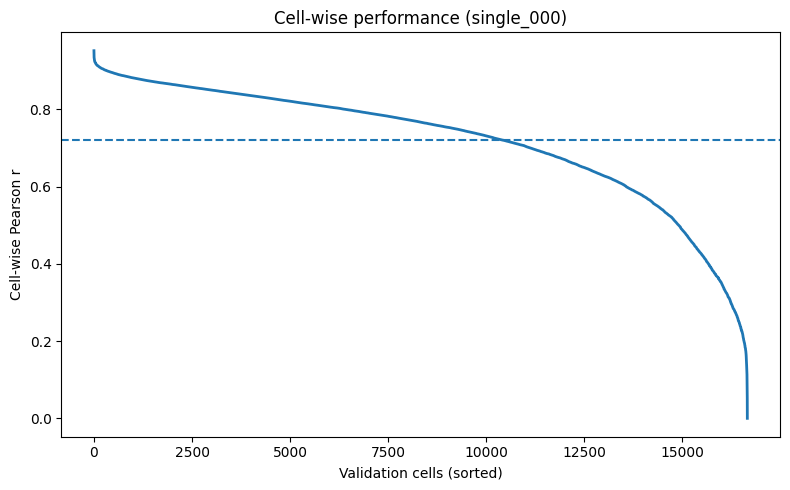

In [12]:
cell_cor_sorted = np.sort(cell_cor[~np.isnan(cell_cor)])[::-1]

plt.figure(figsize=(8, 5))
plt.plot(np.arange(len(cell_cor_sorted)), cell_cor_sorted, linewidth=2)
plt.axhline(np.nanmean(cell_cor), linestyle="--")
plt.xlabel("Validation cells (sorted)")
plt.ylabel("Cell-wise Pearson r")
plt.title(f"Cell-wise performance ({ratio_label})")
plt.tight_layout()
plt.savefig(FIGDIR / "Fig10_sorted_cellwise_correlation.png", dpi=200)
plt.show()

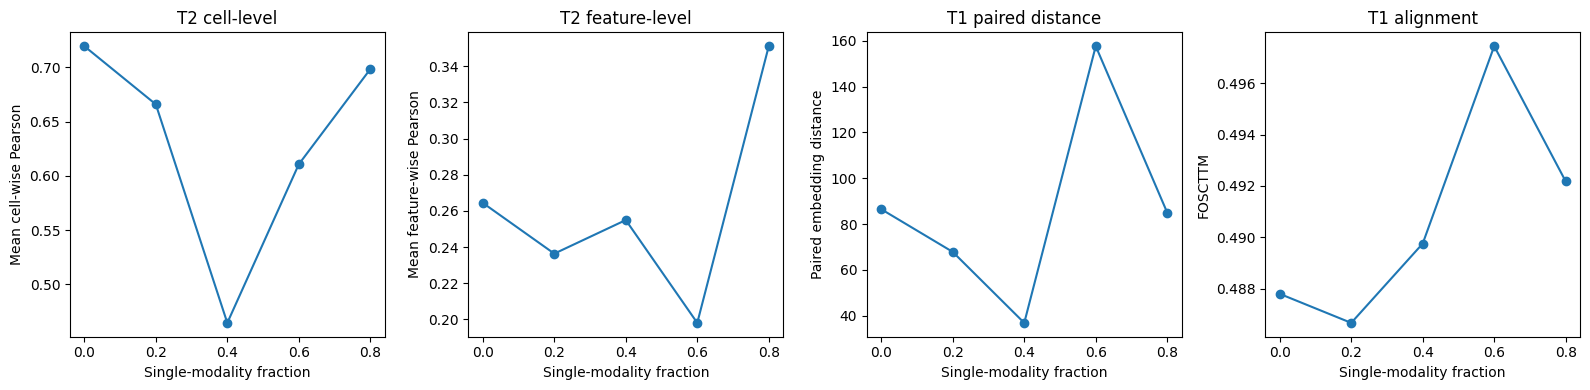

In [13]:
summary_path = BASE_DIR / "summary_all_ratios_scMRDR_rna_to_protein.csv"
summary_df = pd.read_csv(summary_path)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].plot(summary_df["single_frac"], summary_df["cellwise_pearson_mean"], marker="o")
axes[0].set_xlabel("Single-modality fraction")
axes[0].set_ylabel("Mean cell-wise Pearson")
axes[0].set_title("T2 cell-level")

axes[1].plot(summary_df["single_frac"], summary_df["featurewise_pearson_mean"], marker="o")
axes[1].set_xlabel("Single-modality fraction")
axes[1].set_ylabel("Mean feature-wise Pearson")
axes[1].set_title("T2 feature-level")

axes[2].plot(summary_df["single_frac"], summary_df["paired_embedding_distance_mean"], marker="o")
axes[2].set_xlabel("Single-modality fraction")
axes[2].set_ylabel("Paired embedding distance")
axes[2].set_title("T1 paired distance")

axes[3].plot(summary_df["single_frac"], summary_df["foscttm"], marker="o")
axes[3].set_xlabel("Single-modality fraction")
axes[3].set_ylabel("FOSCTTM")
axes[3].set_title("T1 alignment")

plt.tight_layout()
plt.show()

In [14]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
from scipy import sparse
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def to_dense(x):
    if sparse.issparse(x):
        return x.toarray()
    return np.asarray(x)

def get_common_names(*arrays):
    if len(arrays) == 0:
        return []
    common = set(arrays[0])
    for arr in arrays[1:]:
        common &= set(arr)
    return sorted(common)

BASE_DIR = Path("/data5/zhangye/scMRDR/output/BMMC/scMRDR_results_rna_to_protein")
ratio_label = "single_000"
outdir = BASE_DIR / ratio_label
FIGDIR = outdir / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

pred_protein_val = sc.read_h5ad(outdir / "pred_protein_val.h5ad")
true_protein_val = sc.read_h5ad(outdir / "true_protein_val.h5ad")
t1_per_cell = pd.read_csv(outdir / "T1_per_cell_metrics_protein_space.csv")
t2_cellwise = pd.read_csv(outdir / "T2_cellwise_pearson_protein.csv")

common_cells = get_common_names(pred_protein_val.obs_names.tolist(), true_protein_val.obs_names.tolist())
common_features = get_common_names(pred_protein_val.var_names.tolist(), true_protein_val.var_names.tolist())

pred_use = pred_protein_val[common_cells, common_features].copy()
true_use = true_protein_val[common_cells, common_features].copy()

print(pred_use.shape, true_use.shape)

(16658, 102) (16658, 102)


In [15]:
true_mat = to_dense(true_use.X)
pred_mat = to_dense(pred_use.X)

mix = np.vstack([true_mat, pred_mat])   # cells x features
nq = true_mat.shape[0]

mix_adata = ad.AnnData(
    X=mix,
    obs=pd.DataFrame(
        {
            "group": ["True_Protein"] * nq + ["Pred_from_RNA"] * nq,
            "cell": list(common_cells) + list(common_cells),
            "cell_id_plot": [f"true_{c}" for c in common_cells] + [f"pred_{c}" for c in common_cells],
        },
        index=[f"true_{c}" for c in common_cells] + [f"pred_{c}" for c in common_cells],
    ),
    var=pd.DataFrame(index=common_features),
)

sc.pp.normalize_total(mix_adata, target_sum=1e4)
sc.pp.log1p(mix_adata)
sc.pp.scale(mix_adata)
sc.tl.pca(mix_adata, n_comps=min(30, mix_adata.n_obs - 1, mix_adata.n_vars))
sc.pp.neighbors(mix_adata, n_pcs=min(30, mix_adata.obsm["X_pca"].shape[1]))
sc.tl.umap(mix_adata)

umap_df = pd.DataFrame(
    {
        "UMAP1": mix_adata.obsm["X_umap"][:, 0],
        "UMAP2": mix_adata.obsm["X_umap"][:, 1],
        "type": mix_adata.obs["group"].values,
        "cell": mix_adata.obs["cell"].values,
        "cell_id_plot": mix_adata.obs["cell_id_plot"].values,
    },
    index=mix_adata.obs_names,
)

umap_true = umap_df.loc[[f"true_{c}" for c in common_cells]].copy()
umap_pred = umap_df.loc[[f"pred_{c}" for c in common_cells]].copy()

print(umap_df.head())


/home/zhangye/anaconda3/envs/scmrdr/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


                                 UMAP1      UMAP2          type  \
true_AAACCCACAAATGGCG-1-s1d3  5.074031  -1.599835  True_Protein   
true_AAACCCACAAGGAGTC-1-s3d7  4.008617   8.035118  True_Protein   
true_AAACCCACAGATTAAG-1-s4d8  2.445220   9.694686  True_Protein   
true_AAACCCACAGGTGACA-1-s4d9  3.080089   8.324050  True_Protein   
true_AAACCCACATCCGGCA-1-s2d1  4.218615  13.129395  True_Protein   

                                                 cell  \
true_AAACCCACAAATGGCG-1-s1d3  AAACCCACAAATGGCG-1-s1d3   
true_AAACCCACAAGGAGTC-1-s3d7  AAACCCACAAGGAGTC-1-s3d7   
true_AAACCCACAGATTAAG-1-s4d8  AAACCCACAGATTAAG-1-s4d8   
true_AAACCCACAGGTGACA-1-s4d9  AAACCCACAGGTGACA-1-s4d9   
true_AAACCCACATCCGGCA-1-s2d1  AAACCCACATCCGGCA-1-s2d1   

                                              cell_id_plot  
true_AAACCCACAAATGGCG-1-s1d3  true_AAACCCACAAATGGCG-1-s1d3  
true_AAACCCACAAGGAGTC-1-s3d7  true_AAACCCACAAGGAGTC-1-s3d7  
true_AAACCCACAGATTAAG-1-s4d8  true_AAACCCACAGATTAAG-1-s4d8  
true_AAACC

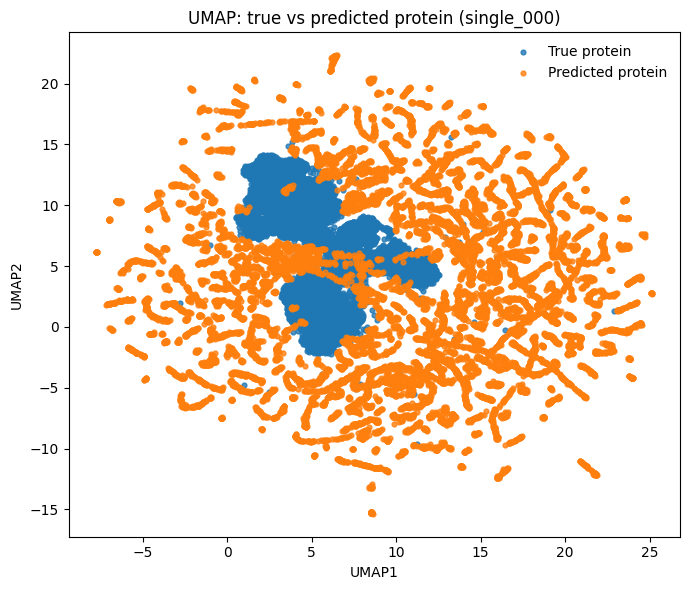

In [16]:
plt.figure(figsize=(7, 6))

mask_true = umap_df["type"] == "True_Protein"
mask_pred = umap_df["type"] == "Pred_from_RNA"

plt.scatter(
    umap_df.loc[mask_true, "UMAP1"],
    umap_df.loc[mask_true, "UMAP2"],
    s=12, alpha=0.8, label="True protein"
)
plt.scatter(
    umap_df.loc[mask_pred, "UMAP1"],
    umap_df.loc[mask_pred, "UMAP2"],
    s=12, alpha=0.8, label="Predicted protein"
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title(f"UMAP: true vs predicted protein ({ratio_label})")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIGDIR / "Fig11_umap_joint_true_vs_pred.png", dpi=200)
plt.show()

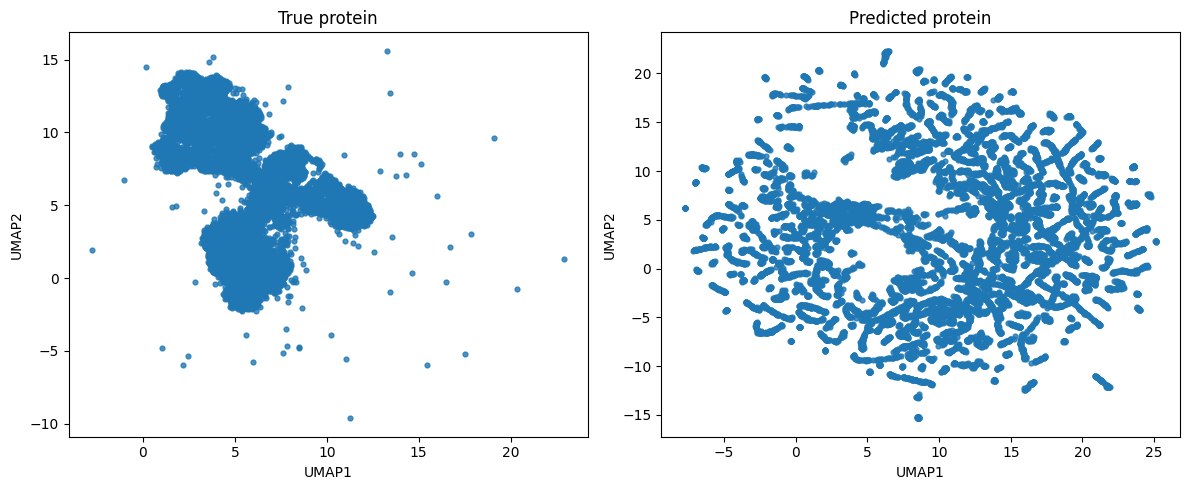

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(umap_true["UMAP1"], umap_true["UMAP2"], s=12, alpha=0.8)
axes[0].set_title("True protein")
axes[0].set_xlabel("UMAP1")
axes[0].set_ylabel("UMAP2")

axes[1].scatter(umap_pred["UMAP1"], umap_pred["UMAP2"], s=12, alpha=0.8)
axes[1].set_title("Predicted protein")
axes[1].set_xlabel("UMAP1")
axes[1].set_ylabel("UMAP2")

plt.tight_layout()
plt.savefig(FIGDIR / "Fig12_umap_true_pred_separate.png", dpi=200)
plt.show()

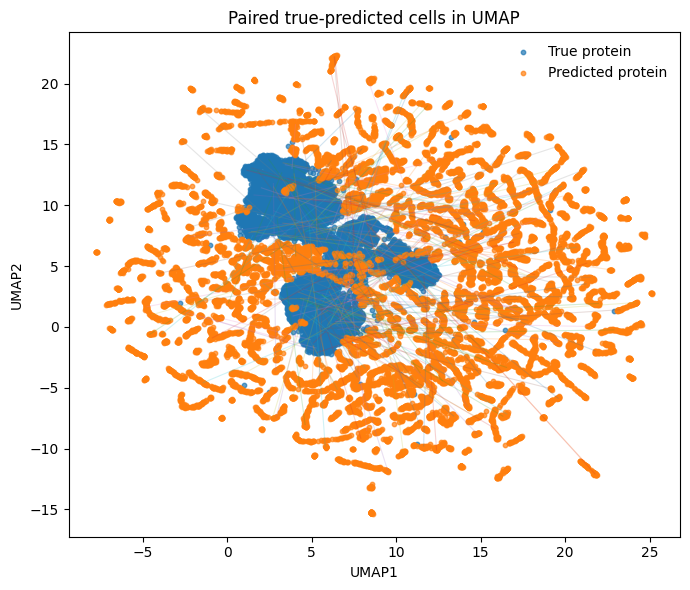

In [18]:
rng = np.random.default_rng(1234)
n_show = min(200, len(common_cells))
show_cells = rng.choice(common_cells, size=n_show, replace=False)

plt.figure(figsize=(7, 6))

plt.scatter(umap_true["UMAP1"], umap_true["UMAP2"], s=10, alpha=0.7, label="True protein")
plt.scatter(umap_pred["UMAP1"], umap_pred["UMAP2"], s=10, alpha=0.7, label="Predicted protein")

for cell in show_cells:
    x0 = umap_true.loc[f"true_{cell}", "UMAP1"]
    y0 = umap_true.loc[f"true_{cell}", "UMAP2"]
    x1 = umap_pred.loc[f"pred_{cell}", "UMAP1"]
    y1 = umap_pred.loc[f"pred_{cell}", "UMAP2"]
    plt.plot([x0, x1], [y0, y1], alpha=0.2, linewidth=0.8)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Paired true-predicted cells in UMAP")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIGDIR / "Fig13_umap_paired_lines.png", dpi=200)
plt.show()

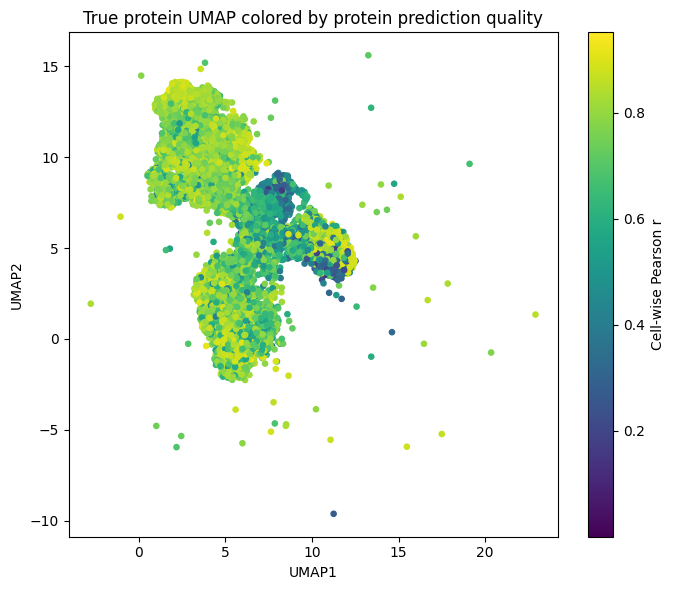

In [19]:
cell_cor_map = dict(zip(t2_cellwise["cell"], t2_cellwise["cellwise_pearson"]))
umap_true_plot = umap_true.copy()
umap_true_plot["cellwise_pearson"] = [cell_cor_map.get(c, np.nan) for c in umap_true_plot["cell"]]

plt.figure(figsize=(7, 6))
scat = plt.scatter(
    umap_true_plot["UMAP1"],
    umap_true_plot["UMAP2"],
    c=umap_true_plot["cellwise_pearson"],
    s=14
)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("True protein UMAP colored by protein prediction quality")
plt.colorbar(scat, label="Cell-wise Pearson r")
plt.tight_layout()
plt.savefig(FIGDIR / "Fig14_umap_true_colored_by_cellcor.png", dpi=200)
plt.show()

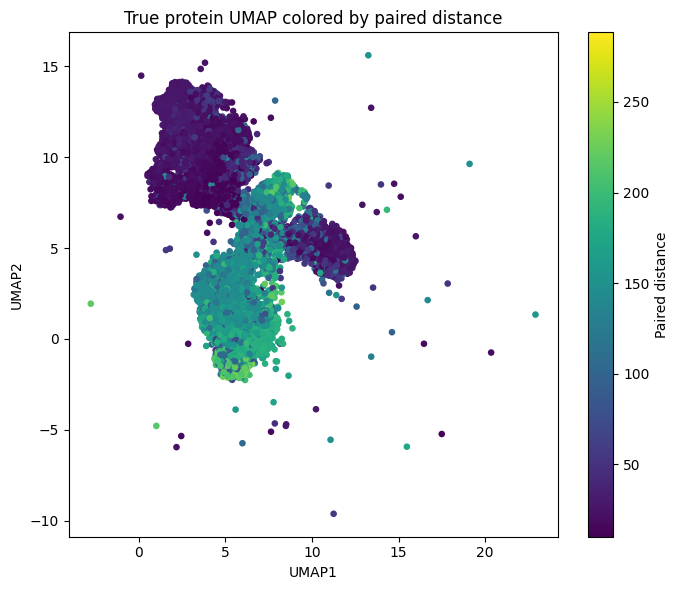

In [20]:
paired_dist_map = dict(zip(t1_per_cell["cell"], t1_per_cell["paired_dist"]))
umap_true_plot["paired_dist"] = [paired_dist_map.get(c, np.nan) for c in umap_true_plot["cell"]]

plt.figure(figsize=(7, 6))
scat = plt.scatter(
    umap_true_plot["UMAP1"],
    umap_true_plot["UMAP2"],
    c=umap_true_plot["paired_dist"],
    s=14
)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("True protein UMAP colored by paired distance")
plt.colorbar(scat, label="Paired distance")
plt.tight_layout()
plt.savefig(FIGDIR / "Fig15_umap_true_colored_by_pairedDist.png", dpi=200)
plt.show()

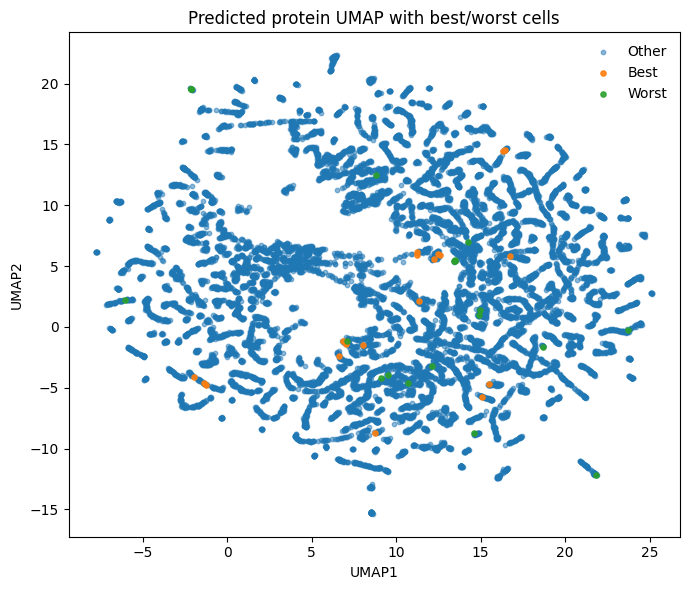

In [21]:
cell_df = t2_cellwise.dropna().sort_values("cellwise_pearson", ascending=False)
best_cells = cell_df["cell"].tolist()[:20]
worst_cells = cell_df["cell"].tolist()[-20:]

umap_pred_plot = umap_pred.copy()
group = []
for c in umap_pred_plot["cell"]:
    if c in best_cells:
        group.append("Best")
    elif c in worst_cells:
        group.append("Worst")
    else:
        group.append("Other")
umap_pred_plot["highlight_group"] = group

plt.figure(figsize=(7, 6))

for g in ["Other", "Best", "Worst"]:
    sub = umap_pred_plot[umap_pred_plot["highlight_group"] == g]
    plt.scatter(
        sub["UMAP1"], sub["UMAP2"],
        s=14 if g != "Other" else 10,
        alpha=0.9 if g != "Other" else 0.5,
        label=g
    )

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Predicted protein UMAP with best/worst cells")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIGDIR / "Fig16_umap_pred_highlight_best_worst.png", dpi=200)
plt.show()

true_protein_data shape: (16658, 102)
pred_protein_data shape: (16658, 102)
n common cells: 16658
n common features: 102
coembed_mat shape: (33316, 102)
obs shape: (33316, 2)
var shape: (102, 0)


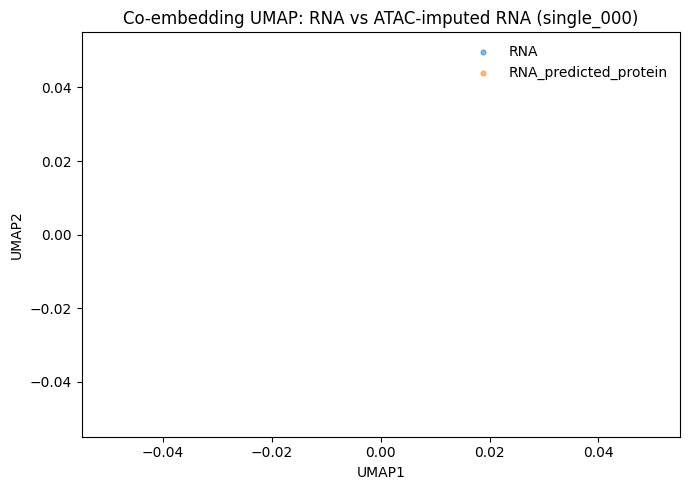

In [22]:
# -------------------------
# Fig17 / Fig18 coembed UMAP
# -------------------------

# 直接从 AnnData 重新取，避免 true_mat / pred_mat 在前面被转置过
true_protein_data = to_dense(true_use.X)   # cells x features
pred_protein_data = to_dense(pred_use.X)  # cells x features

print("true_protein_data shape:", true_protein_data.shape)
print("pred_protein_data shape:", pred_protein_data.shape)
print("n common cells:", len(common_cells))
print("n common features:", len(common_features))

# 检查维度
assert true_protein_data.shape[0] == len(common_cells)
assert pred_protein_data.shape[0] == len(common_cells)
assert true_protein_data.shape[1] == len(common_features)
assert pred_protein_data.shape[1] == len(common_features)

coembed_mat = np.vstack([true_protein_data, pred_protein_data])  # (2*cells) x features

coembed_obs = pd.DataFrame(
    {
        "modality": ["True_Protein"] * len(common_cells) + ["Pred_from_RNA"] * len(common_cells),
        "cell": list(common_cells) + list(common_cells),
    },
    index=[f"{c}_rna" for c in common_cells] + [f"{c}_atac" for c in common_cells],
)

coembed_var = pd.DataFrame(index=common_features)

print("coembed_mat shape:", coembed_mat.shape)
print("obs shape:", coembed_obs.shape)
print("var shape:", coembed_var.shape)

coembed_adata = ad.AnnData(
    X=coembed_mat,
    obs=coembed_obs,
    var=coembed_var,
)

sc.pp.normalize_total(coembed_adata, target_sum=1e4)
sc.pp.log1p(coembed_adata)
sc.pp.scale(coembed_adata, zero_center=True)
sc.tl.pca(coembed_adata, n_comps=min(30, coembed_adata.n_obs - 1, coembed_adata.n_vars))
sc.pp.neighbors(coembed_adata, n_pcs=min(30, coembed_adata.obsm["X_pca"].shape[1]))
sc.tl.umap(coembed_adata)

coembed_df = pd.DataFrame(
    {
        "UMAP1": coembed_adata.obsm["X_umap"][:, 0],
        "UMAP2": coembed_adata.obsm["X_umap"][:, 1],
        "modality": coembed_adata.obs["modality"].values,
        "cell": coembed_adata.obs["cell"].values,
    },
    index=coembed_adata.obs_names,
)

# Fig17
plt.figure(figsize=(7, 5))
for g in ["RNA", "RNA_predicted_protein"]:
    sub = coembed_df[coembed_df["modality"] == g]
    plt.scatter(sub["UMAP1"], sub["UMAP2"], s=12, alpha=0.5, label=g)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title(f"Co-embedding UMAP: RNA vs ATAC-imputed RNA ({ratio_label})")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIGDIR / "Fig17_coembed_umap_rna_vs_atac.png", dpi=200)
plt.show()



In [23]:
true_x = to_dense(true_use.X).ravel()
pred_x = to_dense(pred_use.X).ravel()

print("True mean:", np.mean(true_x), "Pred mean:", np.mean(pred_x))
print("True std :", np.std(true_x),  "Pred std :", np.std(pred_x))
print("True min/max:", np.min(true_x), np.max(true_x))
print("Pred min/max:", np.min(pred_x), np.max(pred_x))

True mean: 0.74424636 Pred mean: 6.33805
True std : 0.7163266 Pred std : 9.4848795
True min/max: 0.0 7.390233
Pred min/max: 0.0142602 128.79182


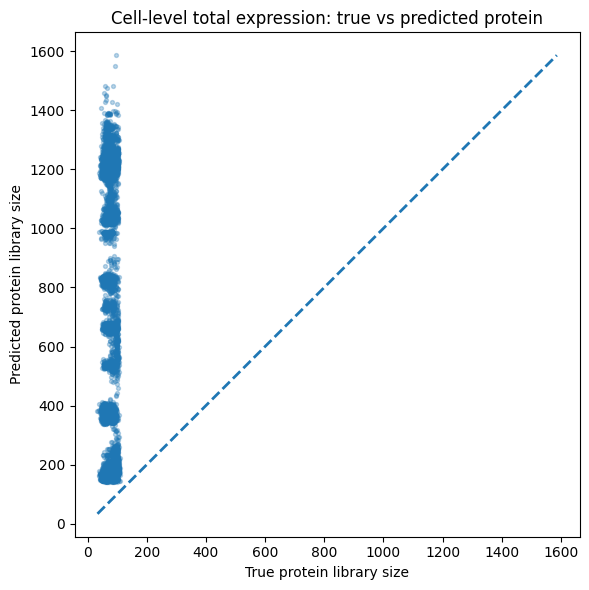

In [24]:
true_lib = np.sum(to_dense(true_use.X), axis=1)
pred_lib = np.sum(to_dense(pred_use.X), axis=1)

plt.figure(figsize=(6, 6))
plt.scatter(true_lib, pred_lib, s=8, alpha=0.3)
mn = min(true_lib.min(), pred_lib.min())
mx = max(true_lib.max(), pred_lib.max())
plt.plot([mn, mx], [mn, mx], linestyle="--", linewidth=2)
plt.xlabel("True protein library size")
plt.ylabel("Predicted protein library size")
plt.title("Cell-level total expression: true vs predicted protein")
plt.tight_layout()
plt.show()

In [25]:
true_protein_data = to_dense(true_use.X)   # cells x features
pred_protein_data = to_dense(pred_use.X)  # cells x features

def zscore_by_feature(mat):
    mu = np.mean(mat, axis=0, keepdims=True)
    sd = np.std(mat, axis=0, keepdims=True)
    sd[sd == 0] = 1.0
    return (mat - mu) / sd

# 分别标准化，再拼接
true_protein_z = zscore_by_feature(true_protein_data)
pred_protein_z = zscore_by_feature(pred_protein_data)

coembed_mat = np.vstack([true_protein_z, pred_protein_z])

coembed_adata = ad.AnnData(
    X=coembed_mat,
    obs=pd.DataFrame(
        {
            "modality": ["True_Protein"] * len(common_cells) + ["Pred_from_RNA"] * len(common_cells),
            "cell": list(common_cells) + list(common_cells),
        },
        index=[f"{c}_rna" for c in common_cells] + [f"{c}_atac" for c in common_cells],
    ),
    var=pd.DataFrame(index=common_features),
)

sc.tl.pca(coembed_adata, n_comps=min(30, coembed_adata.n_obs - 1, coembed_adata.n_vars))
sc.pp.neighbors(coembed_adata, n_pcs=min(30, coembed_adata.obsm["X_pca"].shape[1]))
sc.tl.umap(coembed_adata)